/tmp/ipykernel_20160/3910954706.py:6: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc = QFT(num_qubits=8)
/tmp/ipykernel_20160/3910954706.py:7: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.compose(QFT(num_qubits=8, inverse=True), inplace=True)


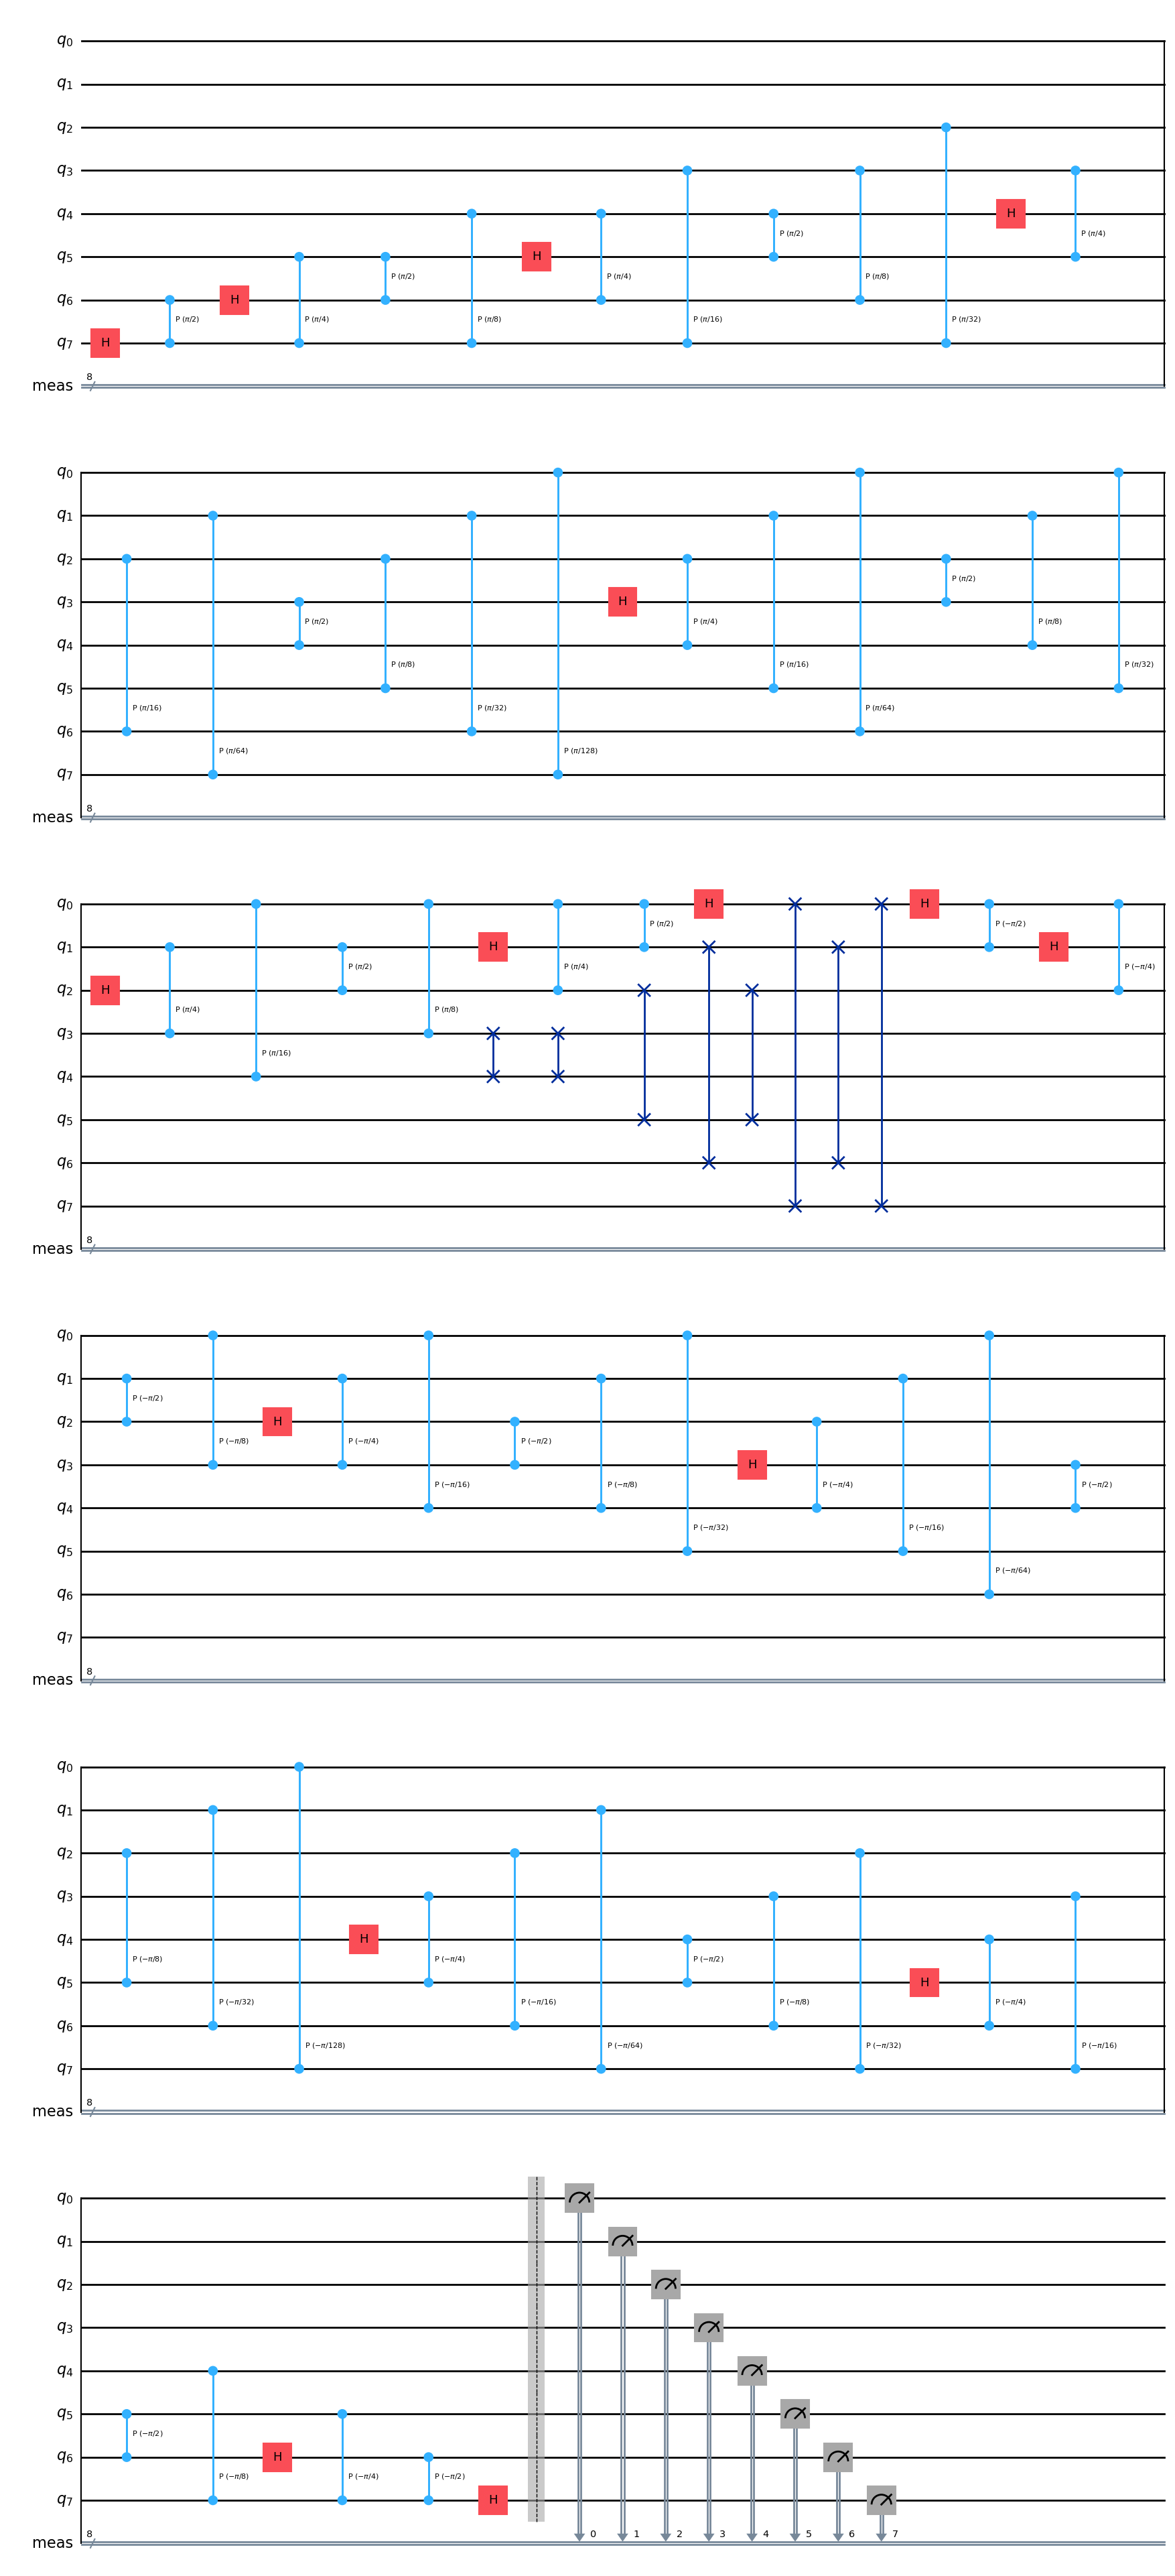

In [14]:
from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.circuit.library import QFT


qc = QFT(num_qubits=8)
qc.compose(QFT(num_qubits=8, inverse=True), inplace=True)
qc = qc.decompose()
qc.measure_all()
qc.draw("mpl")


In [15]:
from qiskit_ibm_runtime.fake_provider import FakeTorino

def get_qc_characteristics(qc):
    # Your work goes here!
    # determine the quantum circuit depth of `qc` and assign it to `depth`
    depth = qc.depth()
    # determine the number of qubits in `qc` and assign it to `num_qubits`    
    num_qubits = qc.num_qubits
    # determine the operations in `qc` and assign it to `ops`
    ops = qc.count_ops()
    # determine the number of n-qubit operations (with n larger than 1) in `qc` and assign it to `num_multi_qubit_ops`, 
    num_multi_qubit_ops = qc.num_nonlocal_gates()
    # do not modify the next line
    return {"depth":depth, "num_qubits":num_qubits, "ops":ops, "num_multi_qubit_ops": num_multi_qubit_ops}    



ftorino = FakeTorino()



circuit_dict = {}
pm_dict = {}

for i in range(0, 4):
    pm = generate_preset_pass_manager(backend=ftorino, optimization_level=i)
    pm_dict[str(i)] = pm 
    isa_qc = pm.run(qc)
    pm.draw(filename=f"pm_level_{i}.png")
    circuit_dict[f"isa_qc{i}"] = pm.run(qc)




/home/aashay/anaconda3/envs/qamp/lib/python3.11/site-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (91587691 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/home/aashay/anaconda3/envs/qamp/lib/python3.11/site-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93113692 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


## Some circuit stats after transpiling using different optimizations :

In [16]:
for i in range(4):
    print(f"Optimization level = {i}")
    print(get_qc_characteristics(circuit_dict[f"isa_qc{i}"]))

Optimization level = 0
{'depth': 804, 'num_qubits': 133, 'ops': OrderedDict([('sx', 786), ('rz', 648), ('cz', 385), ('measure', 8), ('barrier', 1)]), 'num_multi_qubit_ops': 385}
Optimization level = 1
{'depth': 555, 'num_qubits': 133, 'ops': OrderedDict([('sx', 484), ('rz', 444), ('cz', 241), ('measure', 8), ('barrier', 1)]), 'num_multi_qubit_ops': 241}
Optimization level = 2
{'depth': 427, 'num_qubits': 133, 'ops': OrderedDict([('sx', 437), ('rz', 225), ('cz', 211), ('measure', 8), ('x', 2), ('barrier', 1)]), 'num_multi_qubit_ops': 211}
Optimization level = 3
{'depth': 305, 'num_qubits': 133, 'ops': OrderedDict([('sx', 327), ('rz', 195), ('cz', 152), ('measure', 8), ('x', 6), ('barrier', 1)]), 'num_multi_qubit_ops': 152}


In [17]:
from qiskit_ibm_runtime import (Session, EstimatorV2 as Estimator, SamplerV2 as Sampler, SamplerOptions)

seed = 42069
shots = 10_000
with Session(backend=ftorino) as session:
    sampler_options = SamplerOptions() 
    # {"simulator":{"seed_simulator":seed}}
    sampler_options.default_shots = shots
    sampler_options.dynamical_decoupling.enable=True
    sampler_options.dynamical_decoupling.sequence_type="XX"
    sampler = Sampler(mode=session, options=sampler_options)
    
    job = sampler.run([(circuit_dict[f"isa_qc{i}"]) for i in range(4)], )

    result = job.result()
        



/home/aashay/anaconda3/envs/qamp/lib/python3.11/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:273: UserWarning: Options {'dynamical_decoupling': {'enable': True, 'sequence_type': 'XX'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


## Effectiveness of preset_passmanager 

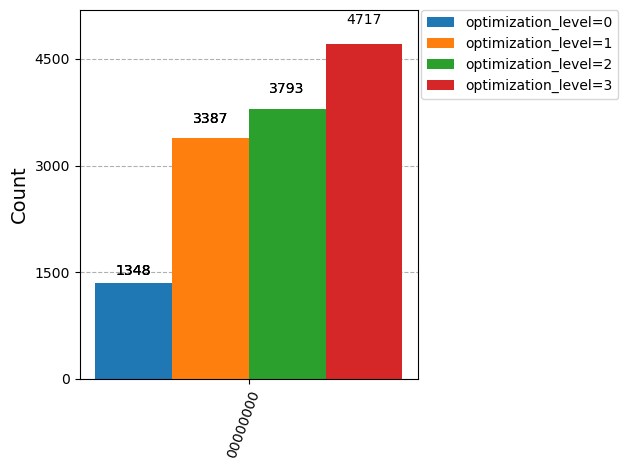

In [18]:
from qiskit.visualization import plot_histogram

plot_histogram([{'0'*8:result[i].data.meas.get_counts()['0'*8]} for i in range(4)], legend=["optimization_level="+str(i) for i in range(4)])



## Do these PMs contatin DD pass?
No. As these are simulators they do not contain a DD passes as DD does not have any improvement in simulation mode. 

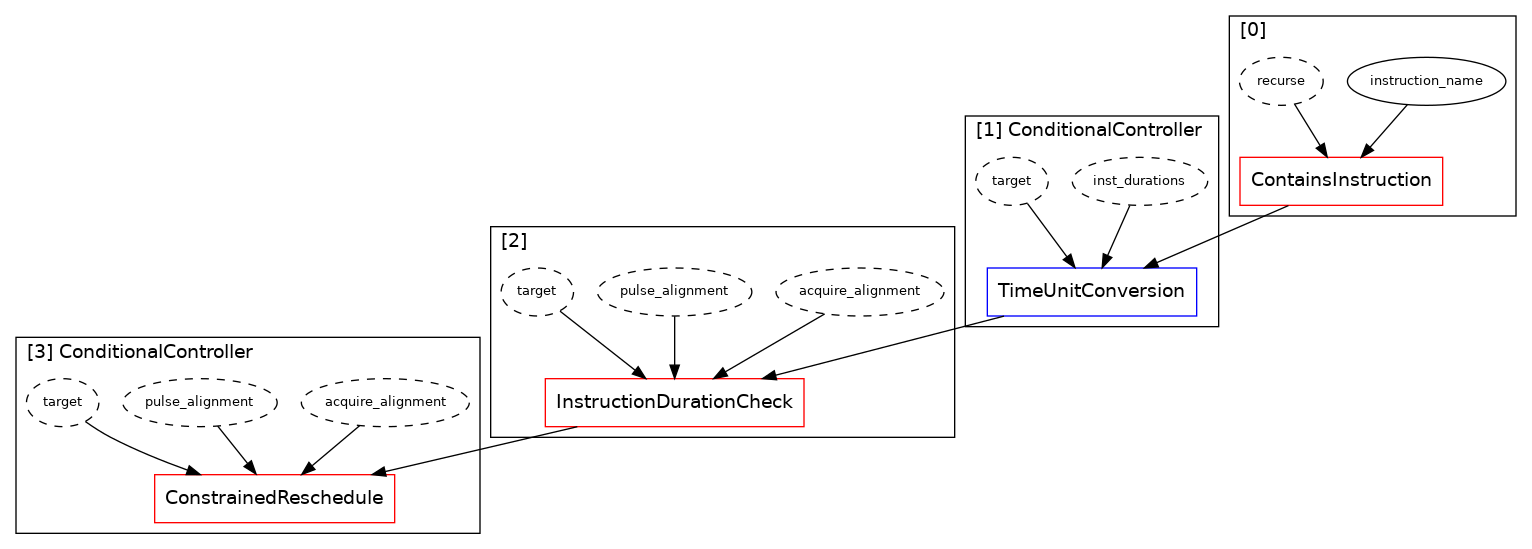

In [19]:
pm2 = pm_dict["2"]
pm2.scheduling.draw()

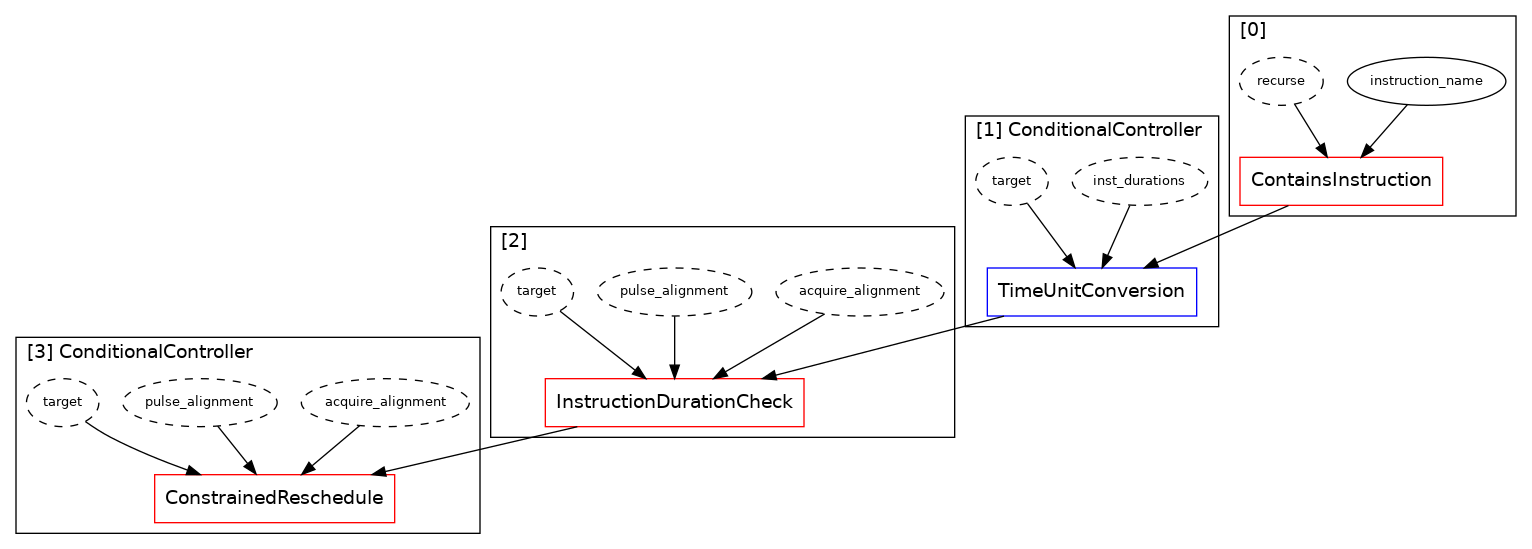

In [20]:
pm3 = pm_dict["3"]
pm3.scheduling.draw()

In [21]:
from qiskit.circuit.library import XGate
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, PadDynamicalDecoupling

target = ftorino.target

X = XGate()
 
dd_sequence = [X, X]

dd_alap_pm = PassManager(
    [
        ALAPScheduleAnalysis(target=target),
        PadDynamicalDecoupling(target=target, dd_sequence=dd_sequence),
    ]
)

dd_circuit = dd_alap_pm.run(circuit_dict["isa_qc2"])


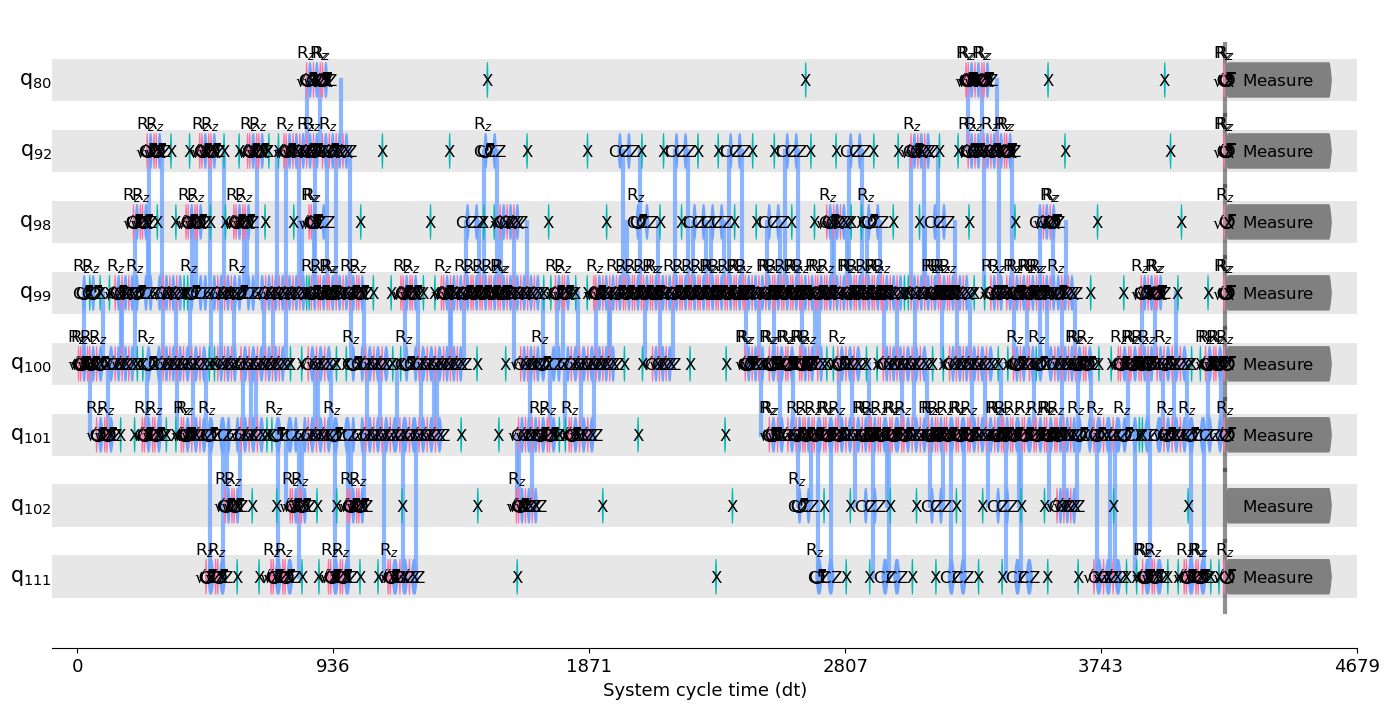

In [22]:
from qiskit.visualization import timeline_drawer
 
timeline_drawer(dd_circuit, idle_wires=False, target=target)

In [23]:
from qiskit.converters import circuit_to_dag
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT, XGate
from qiskit_ibm_runtime.fake_provider import FakeTorino
from qiskit.transpiler import generate_preset_pass_manager, PassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, PadDynamicalDecoupling
import time 


NUM_QUBITS = 4

circuit = QFT(num_qubits=NUM_QUBITS)

circuit.compose(QFT(num_qubits=NUM_QUBITS, inverse=True), inplace=True)
circuit = circuit.decompose()


ftorino = FakeTorino()

pm = generate_preset_pass_manager(backend=ftorino, optimization_level=2)

start = time.time()
opt_circuit = pm.run(circuit)
stop = time.time() - start
target = ftorino.target

print(f"pre-dd transpilation time= {stop}")

X = XGate()
 
dd_sequence = [X, X]

dd_alap_pm = PassManager(
    [
        ALAPScheduleAnalysis(target=target),
        PadDynamicalDecoupling(target=target, dd_sequence=dd_sequence),
    ]
)


# opt_dag = circuit_to_dag(opt_circuit)
# opt_dag.draw(filename="dag_dd.png");
start2 = time.time()
dd_circuit = dd_alap_pm.run(opt_circuit)
stop2 = time.time() - start2

print(f"dd transpilation time= {stop2}")



pre-dd transpilation time= 0.009637594223022461
dd transpilation time= 0.011210441589355469


/tmp/ipykernel_20160/3554633058.py:12: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit = QFT(num_qubits=NUM_QUBITS)
/tmp/ipykernel_20160/3554633058.py:14: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit.compose(QFT(num_qubits=NUM_QUBITS, inverse=True), inplace=True)


In [24]:
# opt_circuit.draw("mpl", idle_wires=False)

In [ ]:
# from qiskit.converters import circuit_to_dag
# alap_pm = ALAPScheduleAnalysis()

# alap_dag = alap_pm.run(circuit_to_dag(opt_circuit))
# alap_dag

AttributeError: 'NoneType' object has no attribute 'dt'

- Run DD experiments with ghz circuit for 7, 8, 9, 10 
- Figure of mertic : hellinger fidelity